<a href="https://colab.research.google.com/github/iamvarshag/Bio-infomatics/blob/Bioinfoexp/Metagenomics_analysis_in_Python_typically_involves_two_distinct_%22layers%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Fetched 255 kB in 1s (200 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provid

/usr/local/lib/python3.12/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:275: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.004346367749864234 whereas the largest positive one is 0.3203570919495472.
  warn(


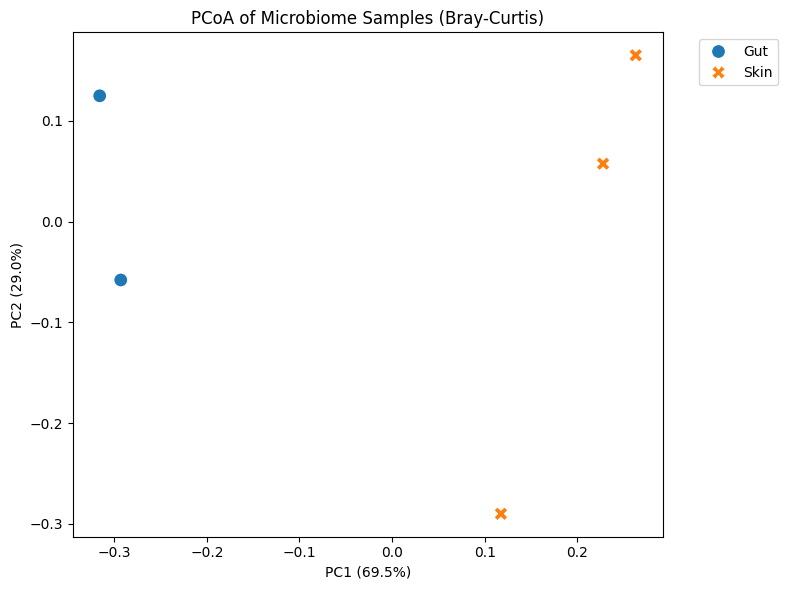

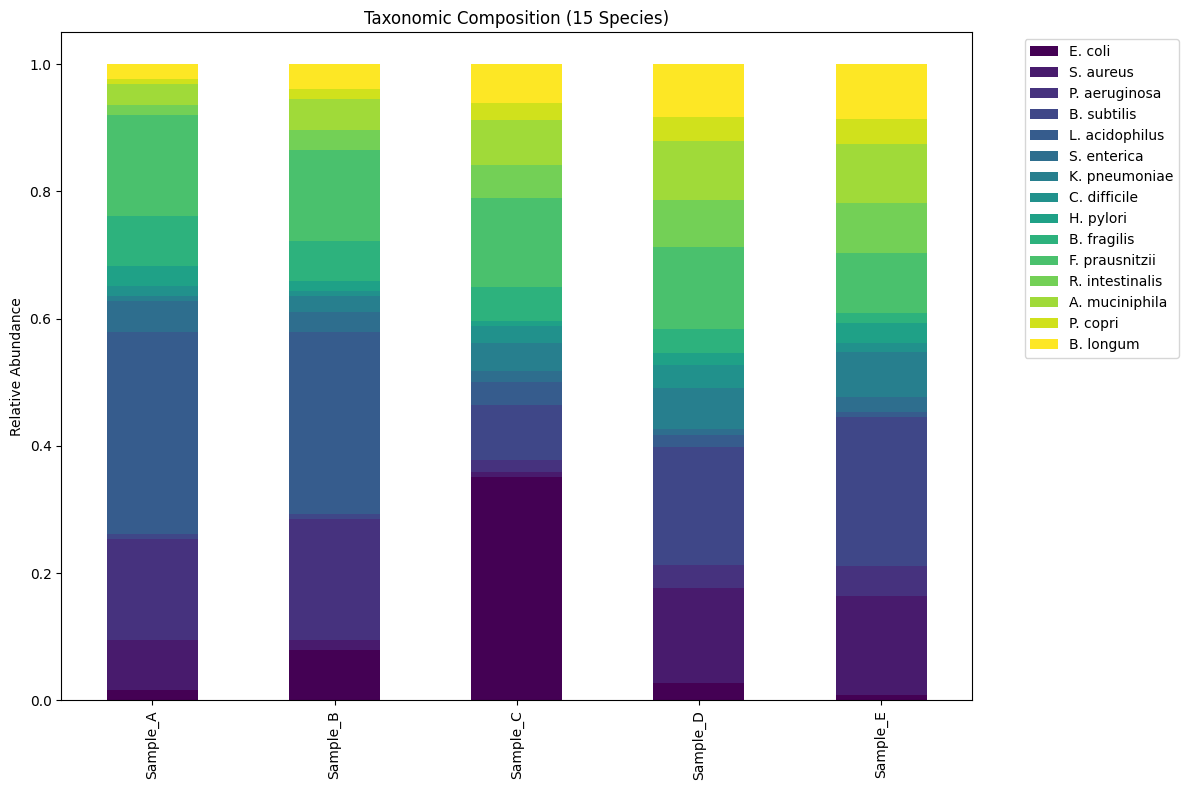

In [ ]:
!pip install scikit-bio
!apt-get update
!apt-get install -y fastp megahit kraken2

import subprocess
import os
import glob

def run_command(cmd, description):
    """Helper to run shell commands with error handling."""
    print(f"--- Running: {description} ---")
    try:
        # shell=True allows using wildcards like *.fastq
        subprocess.run(cmd, shell=True, check=True)
        print(f"--- Finished: {description} ---\n")
    except subprocess.CalledProcessError as e:
        print(f"!!! Error in {description}: {e}")
        # exit(1) # Commenting this out to allow the script to continue if one command fails for demonstration

def pipeline(input_dir, output_dir):
    os.makedirs(input_dir, exist_ok=True) # Ensure input directory exists
    os.makedirs(output_dir, exist_ok=True)

    # --- Create dummy raw data for demonstration if not present ---
    if not glob.glob(f"{input_dir}/*_R1.fastq.gz"):
        print(f"--- Creating dummy data in {input_dir} ---")
        sample_names = ['sampleA', 'sampleB']
        for sn in sample_names:
            # Combined into a single line to avoid multi-line 'with' indentation issues
            with open(f"{input_dir}/{sn}_R1.fastq", 'w') as f_r1, open(f"{input_dir}/{sn}_R2.fastq", 'w') as f_r2:
                f_r1.write(f"@read1_R1_seq1\nAAAAAAAAAAAAAAAGGGGGCGGAG\n+\nJJJJJJJJJJJJJJIJJJJJJJJJ\n@read1_R1_seq2\nTTTTTTTTTTTTTTCCCCCCCCCCCCC\n+\nIIIIIIIIIIIIIIIJJJJJJJJJJJ\n")
                f_r2.write(f"@read1_R2_seq1\nGGGGGGGGGGGGGGCAAAAAAAAAC\n+\nJJJJJJJJJJJJJJIJJJJJJJJJ\n@read1_R2_seq2\nCCCCCCCCCCCCCCCCGGGGGGGGG\n+\nIIIIIIIIIIIIIIIJJJJJJJJJJJ\n")
            # Compress dummy files
            run_command(f"gzip {input_dir}/{sn}_R1.fastq", f"Compressing {sn}_R1")
            run_command(f"gzip {input_dir}/{sn}_R2.fastq", f"Compressing {sn}_R2")
        print(f"--- Dummy data created and compressed ---\n")
    # ------------------------------------------------------------


    # 1. Quality Control (using fastp)
    # Assumes paired-end reads R1 and R2
    r1_files = sorted(glob.glob(f"{input_dir}/*_R1.fastq.gz"))
    r2_files = sorted(glob.glob(f"{input_dir}/*_R2.fastq.gz"))

    if not r1_files or not r2_files:
        print(f"!!! Error: No raw FASTQ.gz files found in {input_dir}. Cannot proceed with QC.")
        return # Exit pipeline if no input files

    qc_dir = os.path.join(output_dir, "qc_reads")
    os.makedirs(qc_dir, exist_ok=True)

    for r1, r2 in zip(r1_files, r2_files):
        sample_name = os.path.basename(r1).split("_R1")[0]

        qc_cmd = (
            f"fastp -i {r1} -I {r2} "
            f"-o {qc_dir}/{sample_name}_R1_clean.fastq.gz "
            f"-O {qc_dir}/{sample_name}_R2_clean.fastq.gz "
            f"-h {qc_dir}/{sample_name}_fastp.html -j {qc_dir}/{sample_name}_fastp.json"
        )
        run_command(qc_cmd, f"QC for {sample_name}")

    # 2. Assembly (using MEGAHIT)
    # We co-assemble all clean reads for this example
    assembly_out = os.path.join(output_dir, "assembly")
    # Ensure qc_dir exists and contains files before trying to glob
    if not os.path.exists(qc_dir):
        print(f"!!! Error: QC directory {qc_dir} does not exist. Cannot proceed with assembly.")
        return

    reads_1 = ",".join(glob.glob(f"{qc_dir}/*_R1_clean.fastq.gz"))
    reads_2 = ",".join(glob.glob(f"{qc_dir}/*_R2_clean.fastq.gz"))

    if not reads_1 or not reads_2:
        print(f"!!! Error: No clean FASTQ.gz files found in {qc_dir} for assembly. Cannot proceed.")
        return

    assemble_cmd = (
        f"megahit -1 {reads_1} -2 {reads_2} "
        f"-o {assembly_out} --out-prefix metagenome_assembly"
    )
    run_command(assemble_cmd, "Metagenome Assembly")

    # 3. Taxonomic Classification (using Kraken2)
    # Note: Requires a pre-built Kraken2 database
    kraken_db = "/path/to/kraken_db" # <<< YOU MUST REPLACE THIS WITH YOUR KRAKEN2 DATABASE PATH
    taxonomy_out = os.path.join(output_dir, "taxonomy")
    os.makedirs(taxonomy_out, exist_ok=True)

    # Check if assembly contigs exist before classifying
    contigs_file = f"{assembly_out}/metagenome_assembly.contigs.fa"
    if not os.path.exists(contigs_file):
        print(f"!!! Warning: Assembly contigs file {contigs_file} not found. Skipping Kraken2 classification.")
    else:
        classify_cmd = (
            f"kraken2 --db {kraken_db} --threads 8 --output {taxonomy_out}/kraken.output "
            f"--report {taxonomy_out}/kraken_report.txt "
            f"{assembly_out}/metagenome_assembly.contigs.fa"
        )
        # run_command(classify_cmd, "Kraken2 Classification") # Uncomment if DB is available and path is set
        print("!!! Note: Kraken2 classification is commented out and requires a valid database path.")

if __name__ == "__main__":
    # Example usage
    pipeline(input_dir="./raw_data", output_dir="./results")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.ordination import pcoa

# 1. Load Data (Creating a mock dataset for demonstration)
# Rows = Samples, Columns = Species (Taxa)
data = {
    'E. coli': [10, 50, 200, 15, 5],
    'S. aureus': [50, 10, 5, 80, 100],
    'P. aeruginosa': [100, 120, 10, 20, 30],
    'B. subtilis': [5, 5, 50, 100, 150],
    'L. acidophilus': [200, 180, 20, 10, 5],
    'S. enterica': [30, 20, 10, 5, 15],
    'K. pneumoniae': [5, 15, 25, 35, 45],
    'C. difficile': [10, 5, 15, 20, 10],
    'H. pylori': [20, 10, 5, 10, 20],
    'B. fragilis': [50, 40, 30, 20, 10],
    'F. prausnitzii': [100, 90, 80, 70, 60],
    'R. intestinalis': [10, 20, 30, 40, 50],
    'A. muciniphila': [20, 30, 40, 50, 60],
    'P. copri': [5, 10, 15, 20, 25],
    'B. longum': [15, 25, 35, 45, 55]
}
sample_ids = ['Sample_A', 'Sample_B', 'Sample_C', 'Sample_D', 'Sample_E']
groups = ['Gut', 'Gut', 'Skin', 'Skin', 'Skin'] # Metadata for coloring

df = pd.DataFrame(data, index=sample_ids)
print("--- Abundance Table ---")
print(df.head())

# 2. Alpha Diversity (Within-sample diversity)
# Metrics: 'shannon', 'simpson', 'chao1'
alpha_shannon = alpha_diversity('shannon', df.values, ids=sample_ids)
alpha_observed = alpha_diversity('observed_features', df.values, ids=sample_ids)

# Combine into a result DataFrame
alpha_results = pd.DataFrame({
    'Shannon': alpha_shannon,
    'Observed_Species': alpha_observed,
    'Group': groups
}, index=sample_ids)

print("\n--- Alpha Diversity ---")
print(alpha_results)

# 3. Beta Diversity (Between-sample diversity)
# Metric: 'braycurtis' is common for abundance data
distance_matrix = beta_diversity('braycurtis', df.values, ids=sample_ids)

print("\n--- Bray-Curtis Distance Matrix ---")
print(distance_matrix)

# 4. PCoA (Principal Coordinates Analysis)
# Dimensionality reduction to visualize the distance matrix
pcoa_results = pcoa(distance_matrix)

# Plotting PCoA
plt.figure(figsize=(8, 6))
pcoa_df = pcoa_results.samples
pcoa_df['Group'] = groups

sns.scatterplot(x='PC1', y='PC2', hue='Group', style='Group', s=100, data=pcoa_df)

# Add percentage explanation to axes
pc1_pct = pcoa_results.proportion_explained['PC1'] * 100
pc2_pct = pcoa_results.proportion_explained['PC2'] * 100
plt.xlabel(f'PC1 ({pc1_pct:.1f}%)')
plt.ylabel(f'PC2 ({pc2_pct:.1f}%)')
plt.title('PCoA of Microbiome Samples (Bray-Curtis)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Taxonomy Bar Plot (Stacked)
# Normalize data to relative abundance (0 to 1)
df_rel = df.div(df.sum(axis=1), axis=0)

df_rel.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 8)) # Increased figsize
plt.ylabel('Relative Abundance')
plt.title('Taxonomic Composition (15 Species)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()